<a href="https://colab.research.google.com/github/Kiritthika03/TeslaStockForecast-LSTM/blob/main/Tesla_stock_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('/content/Tesla.csv')

# Read the data:
Within the dataset one will encounter the following:

The date - "Date"

The opening price of the stock - "Open"

The high price of that day - "High"

The low price of that day - "Low"

The closed price of that day - "Close"

The amount of stocks traded during that day - "Volume"

In [ ]:
data

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.000000,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.420000,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.920000,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.100000,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.000000,15.830000,16.110001,6866900,16.110001
...,...,...,...,...,...,...,...
1687,3/13/2017,244.820007,246.850006,242.779999,246.169998,3010700,246.169998
1688,3/14/2017,246.110001,258.119995,246.020004,258.000000,7575500,258.000000
1689,3/15/2017,257.000000,261.000000,254.270004,255.729996,4816600,255.729996
1690,3/16/2017,262.399994,265.750000,259.059998,262.049988,7100400,262.049988


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


### **We create a subset of data called `df`. Further, we use this dataset to forecast our stock price.**

In [ ]:
df = data[['Date','Close']].copy()
df

,Date,Close
0,6/29/2010,23.889999
1,6/30/2010,23.830000
2,7/1/2010,21.959999
3,7/2/2010,19.200001
4,7/6/2010,16.110001
...,...,...
1687,3/13/2017,246.169998
1688,3/14/2017,258.000000
1689,3/15/2017,255.729996
1690,3/16/2017,262.049988


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

### We plot the `df`

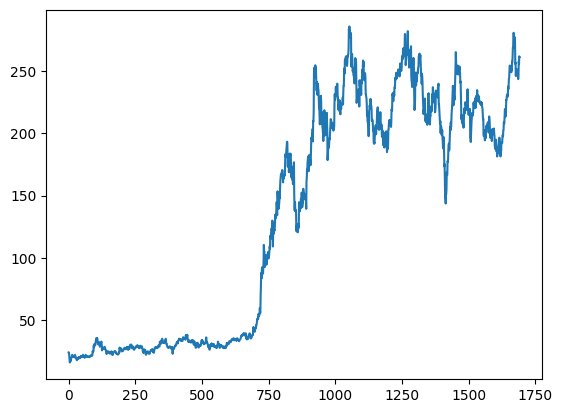

In [ ]:
df2 = df.reset_index()['Close']
plt.plot(df2)

## **What is the graph about?**
Time Series Plot of 'Close' Prices: The line plot represents how the 'Close' price of a stock changes over time.

## **Insights:**
- **Initial Flat Period**: In the beginning (on the left side of the graph), the line is relatively flat, meaning the 'Close' prices stayed low and didn’t change much over time.

- **Sharp Increase**: Around the middle of the graph (around the 750 mark on the x-axis), the line suddenly jumps up, showing that the 'Close' price rose quickly. This could mean the stock or asset gained a lot of value during this period.

- **Fluctuations/Volatility**: After that sharp rise, the line goes up and down, which shows that the prices started to fluctuate a lot, sometimes rising and sometimes falling. This kind of movement suggests the price became more unstable or volatile.

## **Data pre processing:**

### MinMaxScaler:
From sklearn, we import MinMaxScaler to scale the Close column to a range of (0,1) because it has high prices, which can affect the prediction.

### Train-Test split:

We manually split the data into train and test sets because manual train-test splitting in stock price forecasting with LSTM models is essential to prevent overfitting, realistically evaluate the model's performance, avoid data leakage, and maintain the time sequence of the data.
- We split the data into 65% training data and 35% testing data.

### Create_dataset

In this section, we define a function called create_dataset, which takes dataset and time_step as two parameters. Since we know that the current price at a given time step depends on the price at previous time steps, we create this function to structure the data accordingly

we have a list of prices: [120, 130, 150, 230, 400, 450, 203, 500, 340, 230]. The create_dataset function is designed to take a time_step (in this case, 3) and create sequences of prices where each sequence is used to predict the next price. For instance, the first sequence [120, 130, 150] has `230` as the next price, so the function pairs these as input and output. Similarly, the second sequence [130, 150, 230] has `400` as the next price. This continues for the rest of the dataset, creating a structure where past prices are used to predict the future ones. Here's how the data is split:

f1  f2. f3.  o/p

120 130 150. 230

130 150 230  400

In [ ]:
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()
df2 = ms.fit_transform(np.array(df2).reshape(-1,1))
df2.shape

(1692, 1)

In [ ]:
train_size = int(len(df2)*0.65)
test_size = len(df2) - train_size
train_data,test_data = df2[0:train_size,:],df2[train_size:len(df2),:1]

In [ ]:
def create_dataset(dataset, time_step = 1):
  dataX,dataY = [],[]
  for i in range(len(dataset)-time_step-1):
    a = dataset[i:(i+time_step),0]
    dataX.append(a)
    dataY.append(dataset[i+time_step,0])
  return np.array(dataX),np.array(dataY)

In [ ]:
time_step = 100
X_train,y_train = create_dataset(train_data,time_step)
X_test,y_test = create_dataset(test_data,time_step)

In [ ]:
# checking values
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(998, 100)
(998,)
(492, 100)
(492,)


## **Creating LSTM**

In this section, we are building an LSTM model using the Keras framework.

1. We define a Sequential model, which means that layers will be added to the model one by one in a sequential manner.

2. This defines the input layer: We specifies the input shape. 1 indicates that each time step has a single feature (e.g., the "Close" price).

3. LSTM Layers: Long Short-Term Memory (LSTM) layers are used to capture patterns in sequential data over time.
- The first two LSTM layers have return_sequences=True because they pass the sequence to the next LSTM layer.
- The final LSTM layer doesn’t need return_sequences=True because it outputs a single value to the next layer, which is the Dense (output) layer.

4. The Dense layer is a fully connected layer that acts as the output layer in this model.

5. The model is compiled with Mean Squared Error as the loss function and the Adam optimizer, preparing it for training.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

# Define the model
model = Sequential()

# First layer is an Input layer to define the input shape explicitly
model.add(Input(shape=(X_train.shape[1], 1)))

# Adding the LSTM layers
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))

# Adding the output layer (Dense layer for regression)
model.add(Dense(1))

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

# Display the summary of the model
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 100, 50)             │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

## The model has been trained for 50 epochs each with a batch size of 64.

In [ ]:
model.fit(X_train,y_train,validation_data = (X_test,y_test),epochs = 50,batch_size = 64,verbose = 1)


Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - loss: 0.0019 - val_loss: 0.0036
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 184ms/step - loss: 0.0017 - val_loss: 0.0035
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - loss: 0.0017 - val_loss: 0.0034
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - loss: 0.0015 - val_loss: 0.0043
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 178ms/step - loss: 0.0017 - val_loss: 0.0048
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - loss: 0.0017 - val_loss: 0.0030
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - loss: 0.0013 - val_loss: 0.0030
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - loss: 0.0013 - val_loss: 0.0031
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - loss: 0.0013 - val_loss: 0.0026
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 240ms/step - loss: 0.0012 - val_loss: 0.0030
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - loss: 0.0011 - val_loss: 0.0026
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step

## **Prediction and checking performance matrix**

1. we generate predictions based on training and test data.

2. We used to reverse this scaling so that the predicted values are brought back to their original scale (such as actual stock prices). This allows the predicted values to be compared with the actual values on the correct scale.

3. RMSE (Root Mean Squared Error) is a common metric to measure the performance of regression models. It calculates how close the predicted values are to the actual values. The lower the RMSE, the better the model's performance.


In [ ]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


In [ ]:
train_predict = ms.inverse_transform(train_predict)
test_predict = ms.inverse_transform(test_predict)

In [ ]:
import math
from sklearn.metrics import mean_squared_error

In [ ]:
print(math.sqrt(mean_squared_error(y_train,train_predict)))
print(math.sqrt(mean_squared_error(y_test,test_predict)))

0.027717660013609022
0.04154373167898995


## Graph:
1. It creates empty arrays to hold the predictions for both the training and test sets, ensuring that predictions are plotted in the right place on the graph.
2. It fills the arrays with the model's predictions for both the training and test sets, leaving NaN for the parts of the graph where predictions can't be made (like the initial look_back period).
3. Finally, it plots the original data alongside the model's predictions for both training and test sets so that you can visually compare the actual vs. predicted values

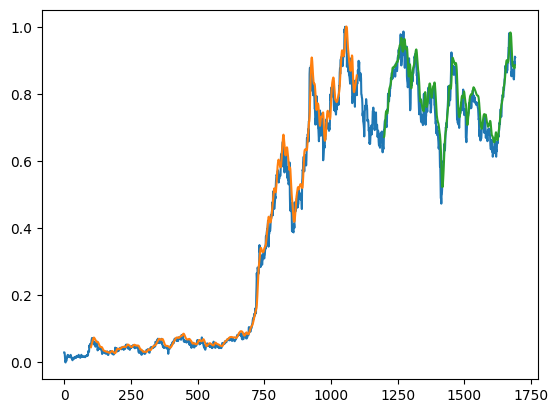

In [ ]:
look_back = 100
trainPredictPlot = np.empty_like(df2)
trainPredictPlot[:,:] = np.nan
trainPredictPlot[look_back : len(train_predict)+look_back,:] = train_predict
testPredictPlot = np.empty_like(df2)
testPredictPlot[:,:] = np.nan
testPredictPlot[len(train_predict)+(look_back)*2 + 1 : len(df2) - 1,:] = test_predict
plt.plot(ms.inverse_transform(df2))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

## Insight:
- Overall, the model performs well on both training and test sets, with the predictions closely matching the actual data for most of the graph.
- There are minor deviations during more volatile periods, but the model - generally tracks the overall trend accurately.
- This means the LSTM model is effective at forecasting stock prices or time series data, but there may be room for improvement in highly fluctuating periods